# Notebook 11 — Morphing Scores Over Time

> **Supplementary §12**

The morphing shape modes provide a compact coordinate system for describing hawk wing-tail shape. This notebook examines how the morphing mode scores vary over the course of a flight, revealing the temporal dynamics of shape change.

We consolidate results from three perspectives:
1. **Flight distance** — how morphing patterns differ across 5 m, 7 m, 9 m, and 12 m flights
2. **Obstacle flights** — how the presence of an obstacle alters morphing trajectories
3. **Individual variation** — per-hawk morphing patterns under different conditions

Scores are binned by horizontal distance to the landing perch (bin size = 0.1 m) and plotted as mean ± 1 standard deviation.

## Contents
1. [Setup and data loading](#setup)
2. [Morphing during varying flight distances](#distances)
3. [Obstacle versus control flights](#obstacle)
4. [Mean scores by individual under different contexts](#individuals)
5. [Summary](#summary)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from kinematic_morphospace import (
    filter_by, run_PCA,
    get_score_df, get_binned_scores,
)
from kinematic_morphospace.plotting import (
    plot_score, plot_score_multi_PCs, plot_score_multi_distance,
    plot_score_multi_bird,
    plot_score_obstacle_control, plot_score_weight_control,
    plot_score_naive_control,
    prepare_heatmap_comparison, plot_difference_PC_scores_heatmap,
    save_figure,
)

## Load Data and Run PCA

We load the rotation-corrected unilateral marker data and rerun PCA (trained on non-obstacle flights, projected onto all data). The scores are then combined with flight metadata and binned by horizontal distance.

In [2]:
unilateral_data = np.load("../../data/unilateral/data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/unilateral/frame_info.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

scores_df, horz_dist_bins = get_score_df(scores, unilateral_frame_info_df, size_bin=0.1)

# Negate PC07 (m-folding) for interpretability: positive = more folded
scores_df["PC07"] = -scores_df["PC07"]

print(f"Total frames: {scores.shape[0]:,}")
print(f"Modes: {scores.shape[1]}")
print(f"Scores dataframe: {scores_df.shape}")

Total frames: 289,528
Modes: 12
Scores dataframe: (289528, 27)


## Morphing During Varying Flight Distances

> **§12.1**

**Note on mode ordering:** For clarity, "collective pitching" (PC08) has been repositioned in these plots; the scores are therefore not strictly ordered by variance explained.

Hawks flew between perches at four distances (5 m, 7 m, 9 m, 12 m) during experimental period 1 (no obstacle, no added weights). Data from one experienced female (Ruby) and three juvenile males (Drogon, Toothless, Charmander).

### All 9 modes — 9 m flights

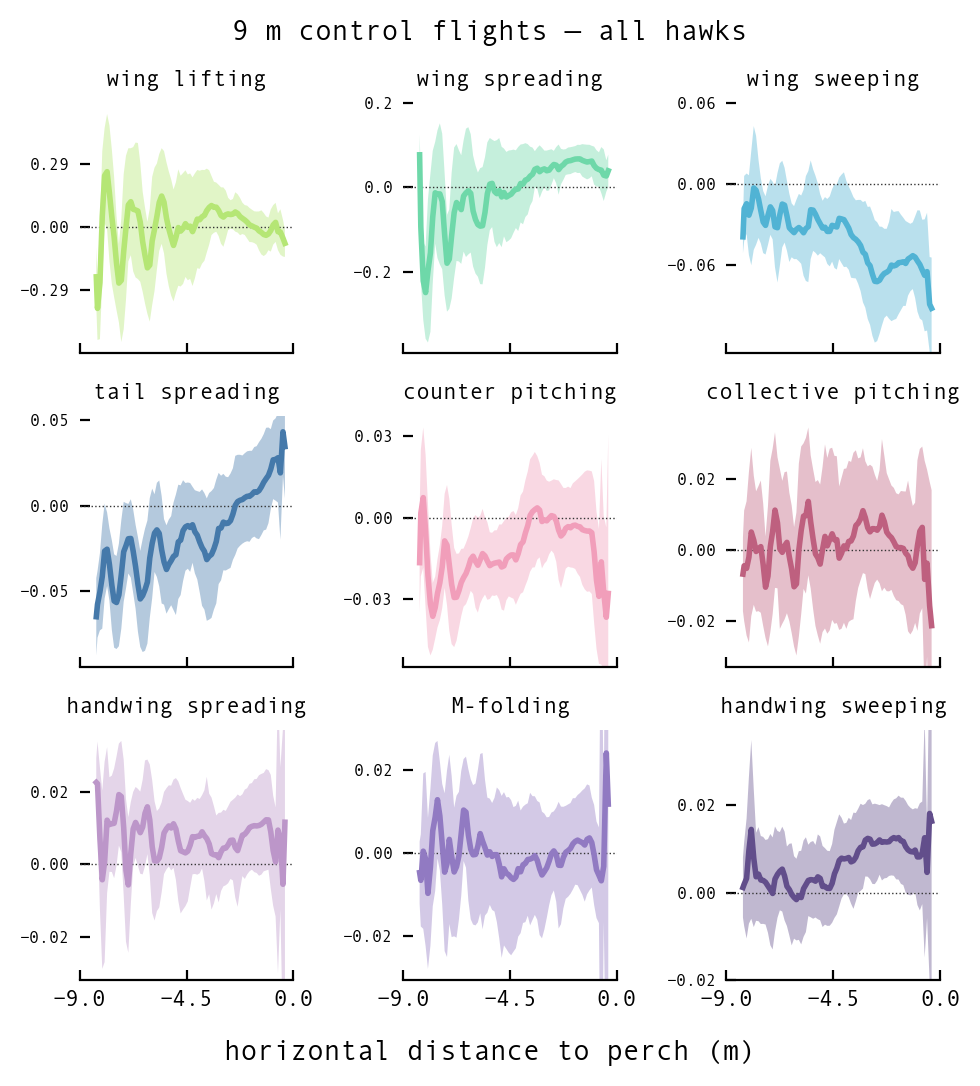

In [3]:
plt.close("all")
fig = plot_score_multi_PCs(scores_df, perchDist=9, obstacle=0, year=2020)
plt.suptitle("9 m control flights — all hawks", fontsize=10, y=1.02)
plt.show()

Saved: ../../figures/supplementary/S12_scores_by_distance_PC01.pdf


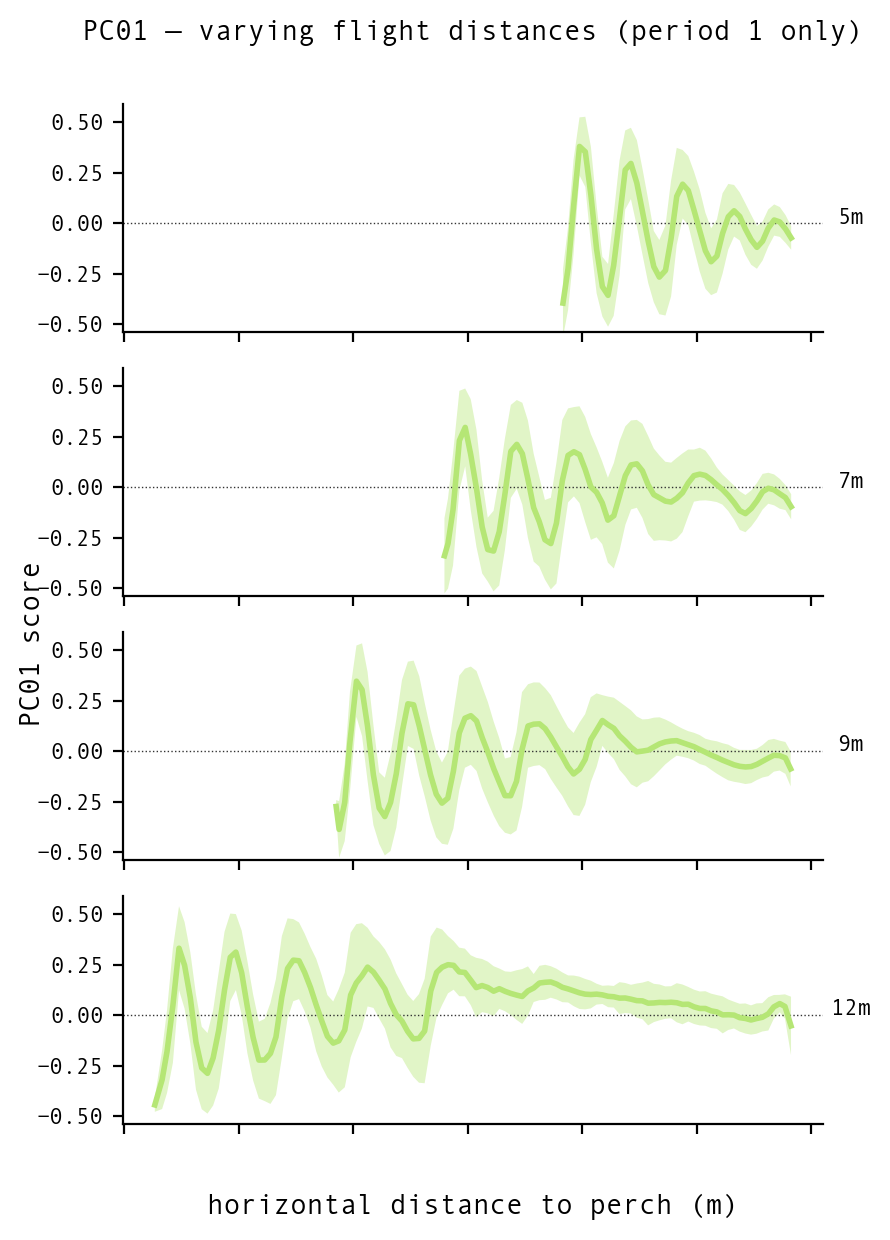

Saved: ../../figures/supplementary/S12_scores_by_distance_PC02.pdf


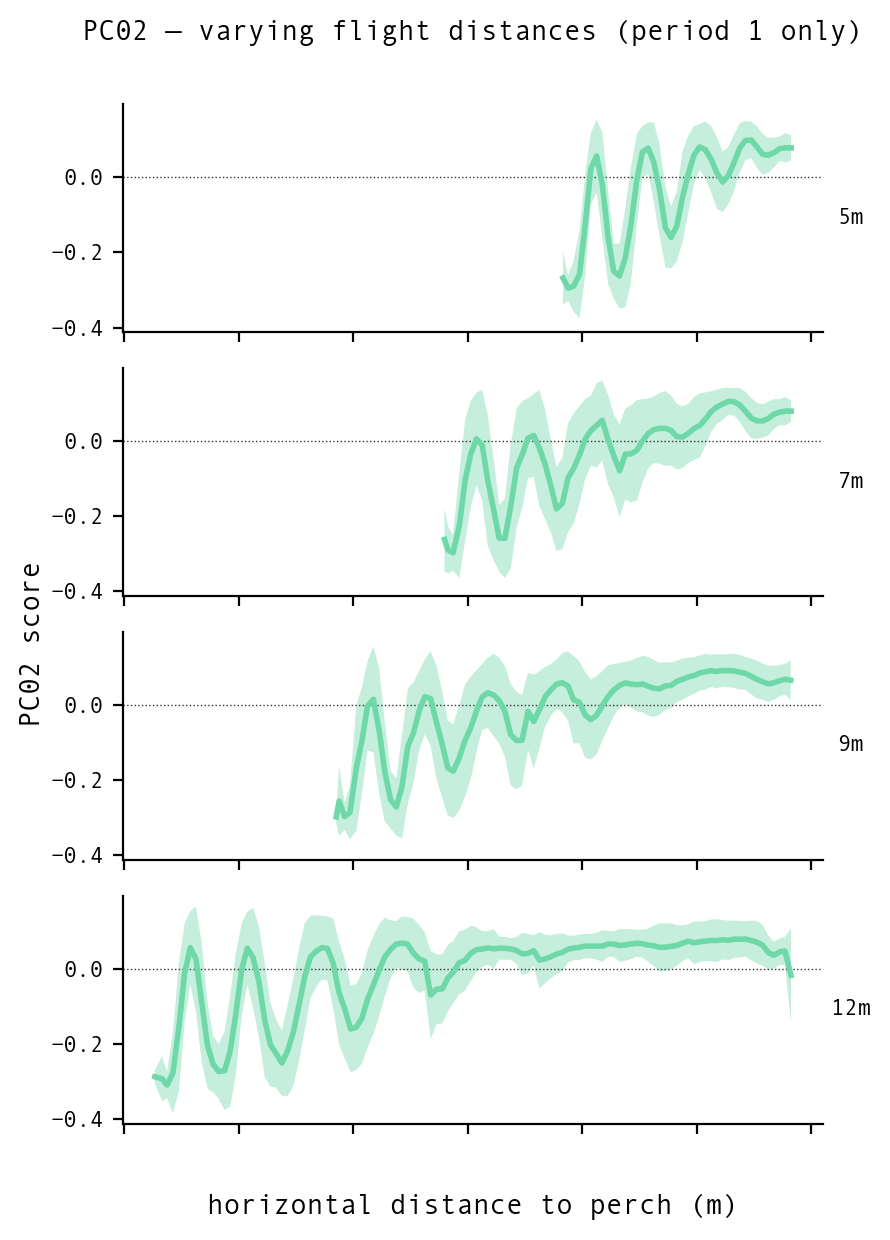

Saved: ../../figures/supplementary/S12_scores_by_distance_PC03.pdf


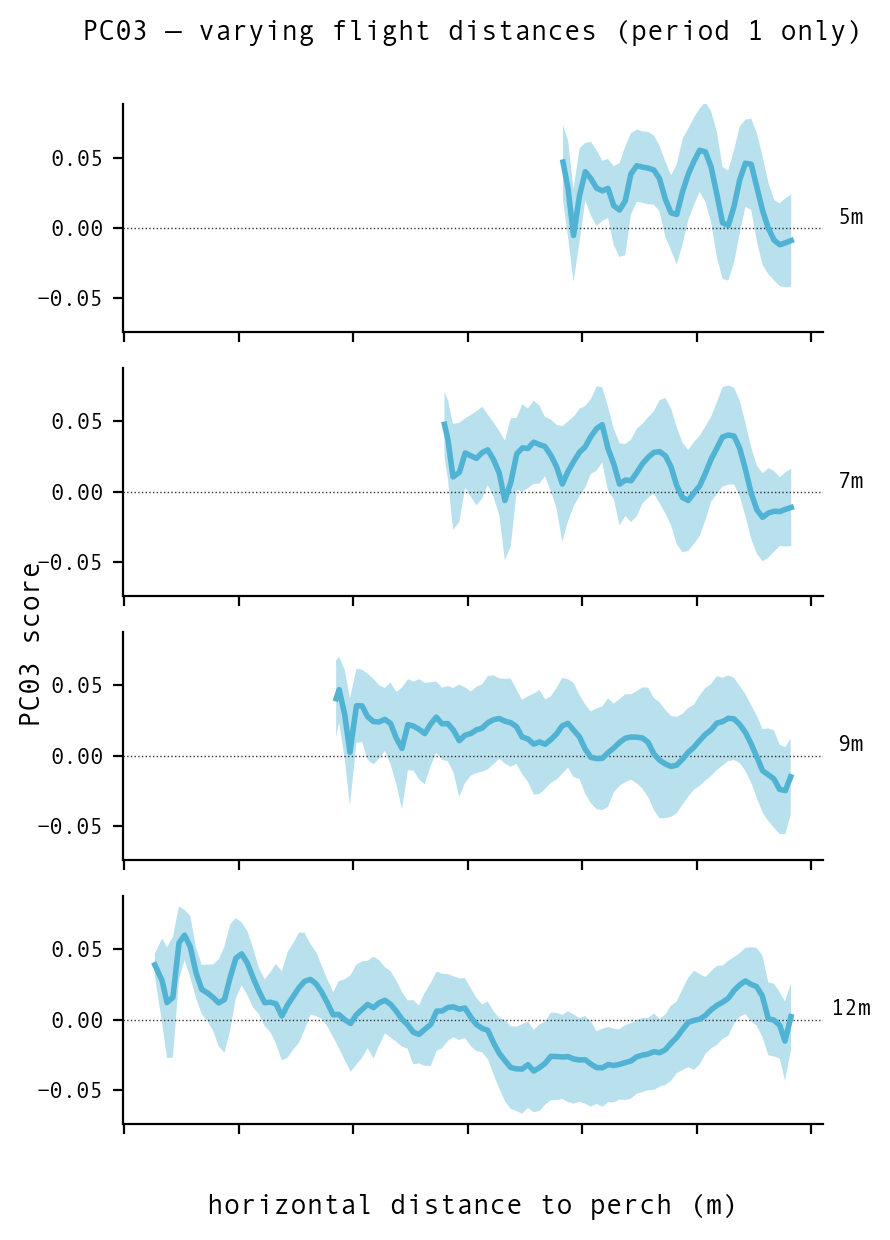

Saved: ../../figures/supplementary/S12_scores_by_distance_PC04.pdf


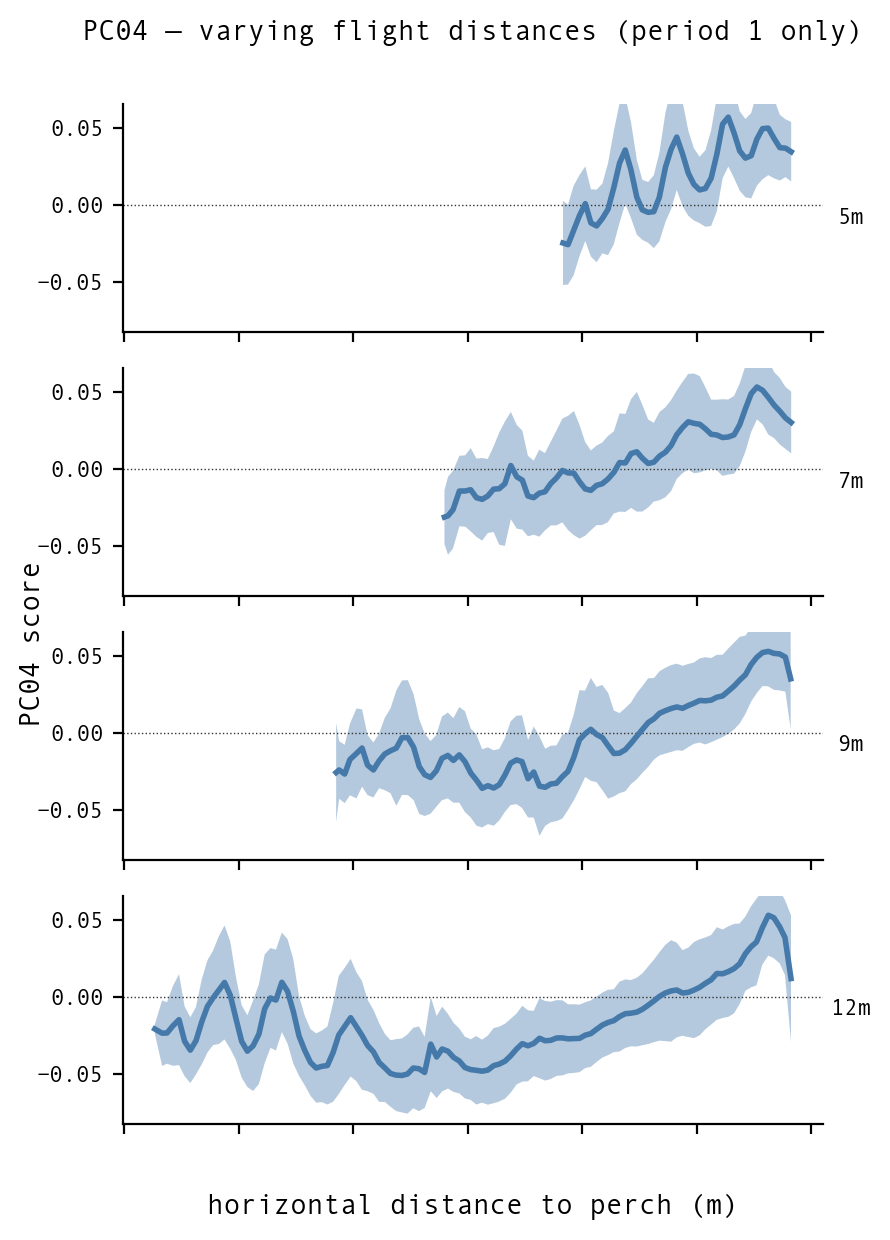

In [4]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_multi_distance(scores_df, pc, obstacle=0, year=2017)
    plt.suptitle(f"{pc} — varying flight distances (period 1 only)", fontsize=10, y=1.02)
    save_figure(fig, f'../../figures/supplementary/S12_scores_by_distance_{pc}.pdf')
    plt.show()

### Key observations from §12.1

**Modes 1–2 (wing lifting and spreading):** Wingbeat cycles are visible in the first few metres of flight. Flapping amplitude decreases with each successive wingbeat while span increases. For longer flights (9 m, 12 m), hawks transition to a glide with maximum spread and steadily lowering wings to neutral. For shorter flights (5 m, 7 m), wingspan steadily increases over the flapping cycles into landing. A small peak in wing lifting occurs in the 1 m before landing.

**Mode 3 (wing sweep):** Sweep oscillates during wingbeat cycles. During 9 m glides, forward-and-backward oscillations continue; in 12 m glides, the wings are more swept back at the glide transition then steadily sweep forwards. Across all distances, a peak of positive (forward) sweep occurs approximately 1.5 m before the perch.

**Mode 4 (tail spreading):** Oscillates with wingbeat cycles and increases on approach to the perch. At landing, tail spread reaches its maximum and then decreases with foot contact (approximately 0.3 m before the perch). At the transition to gliding in the longer flights, tail spread is minimal and then increases through the glide. Tail spreading coincides with the hawks pitching up (see Notebook 03, "Projection to Symmetrical Components").

**Mode 5 (counter-pitching):** The tail lowers whilst the wings pitch in the opposite direction but with smaller magnitude. During flapping, wing pitch oscillates but is on average negative (trailing edge above leading edge). In gliding, wing pitch increases and at maximum — approximately 1.5 m before the perch — the leading and trailing edges are at the same height in the body coordinate space. A sudden reduction in wing pitch occurs approximately 1 m before the perch during rapid whole-body pitch-up. Combined with wings sweeping forward briefly, these shape changes resemble a "shrug" manoeuvre, visible in videos of landing hawks and a steppe eagle (Carruthers et al. 2007). Before this point the covert feathers flip up under stall conditions but suddenly flatten afterwards, suggesting this manoeuvre could be involved with flow reattachment.

### Distance-separated score traces

## Obstacle Versus Control Flights

> **§12.2**

Data from experimental period 2: 9 m flights with and without an obstacle at the midpoint. The obstacle forces the hawk to bank around it, introducing characteristic changes in the morphing scores.

### Time traces — obstacle vs control per hawk

Saved: ../../figures/supplementary/S12_scores_obstacle_control_PC01.pdf


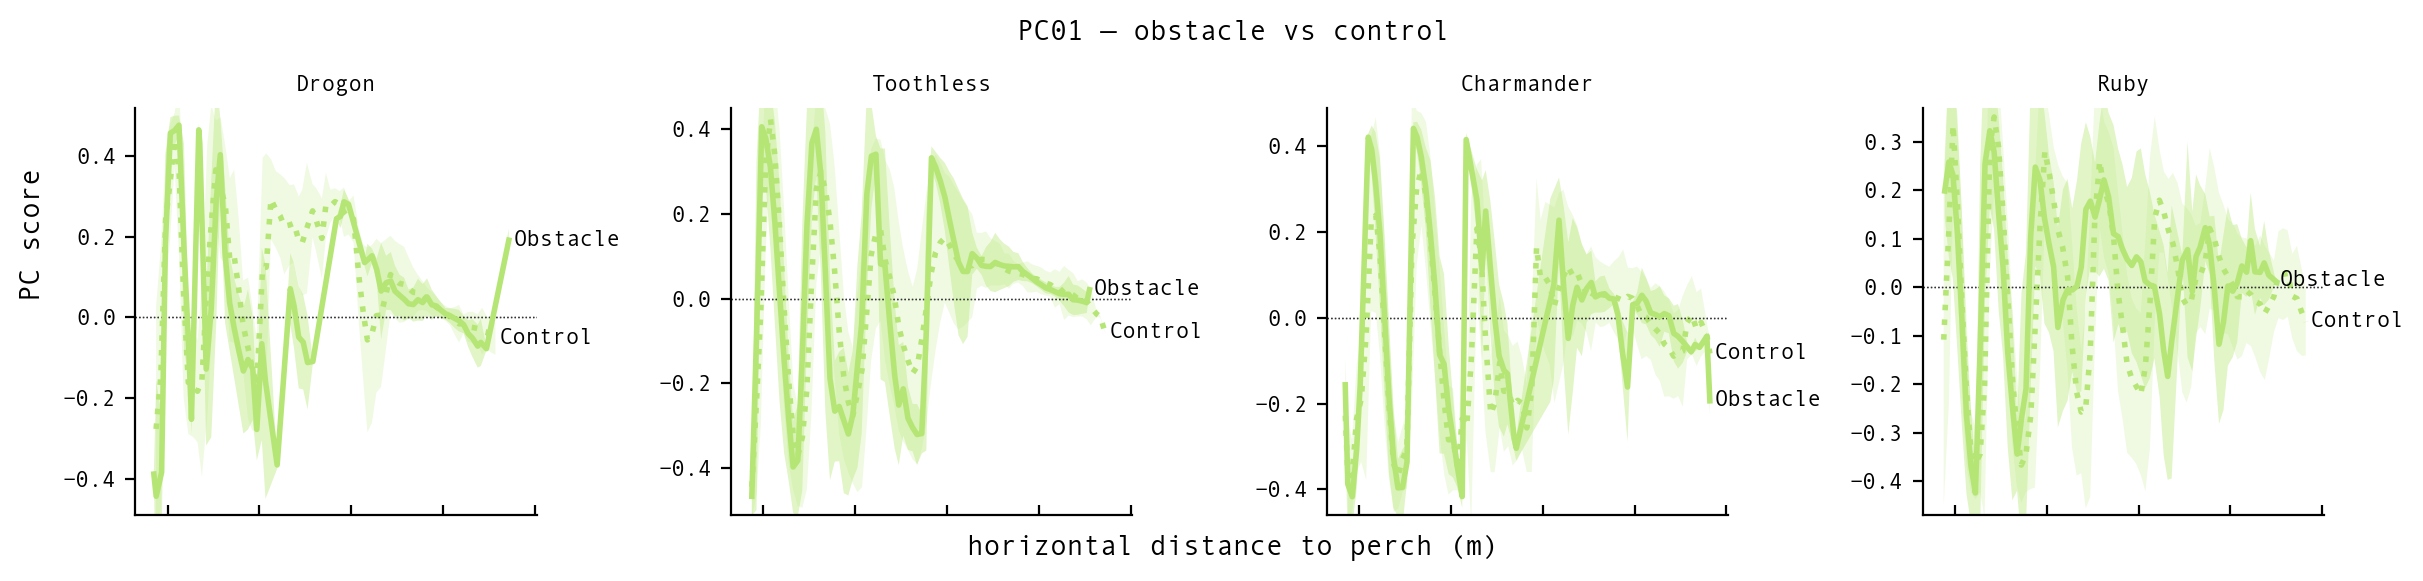

Saved: ../../figures/supplementary/S12_scores_obstacle_control_PC02.pdf


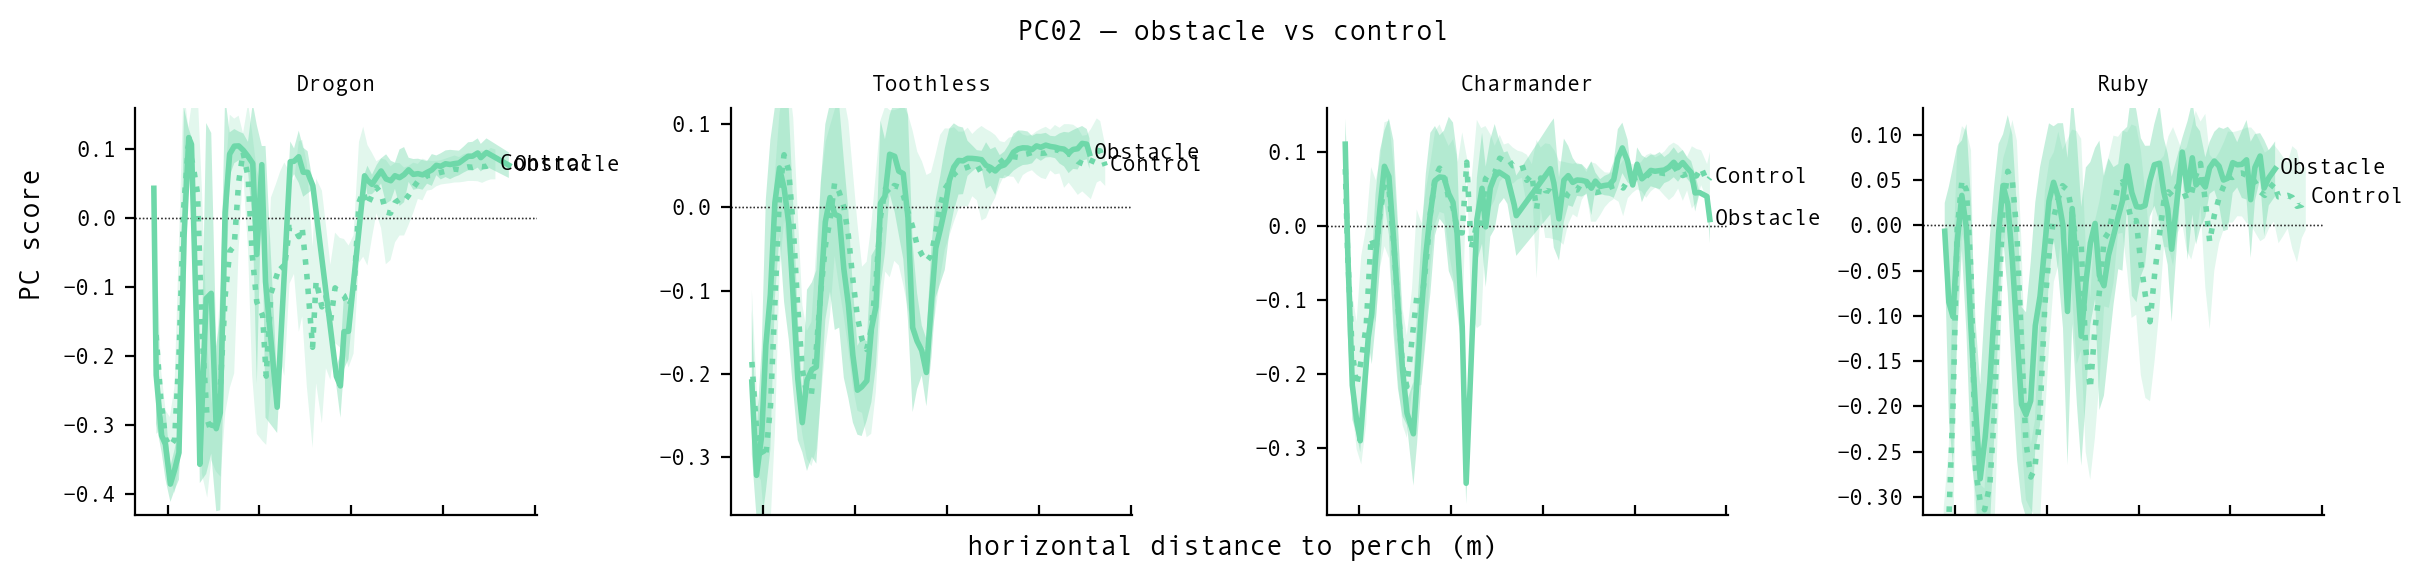

Saved: ../../figures/supplementary/S12_scores_obstacle_control_PC03.pdf


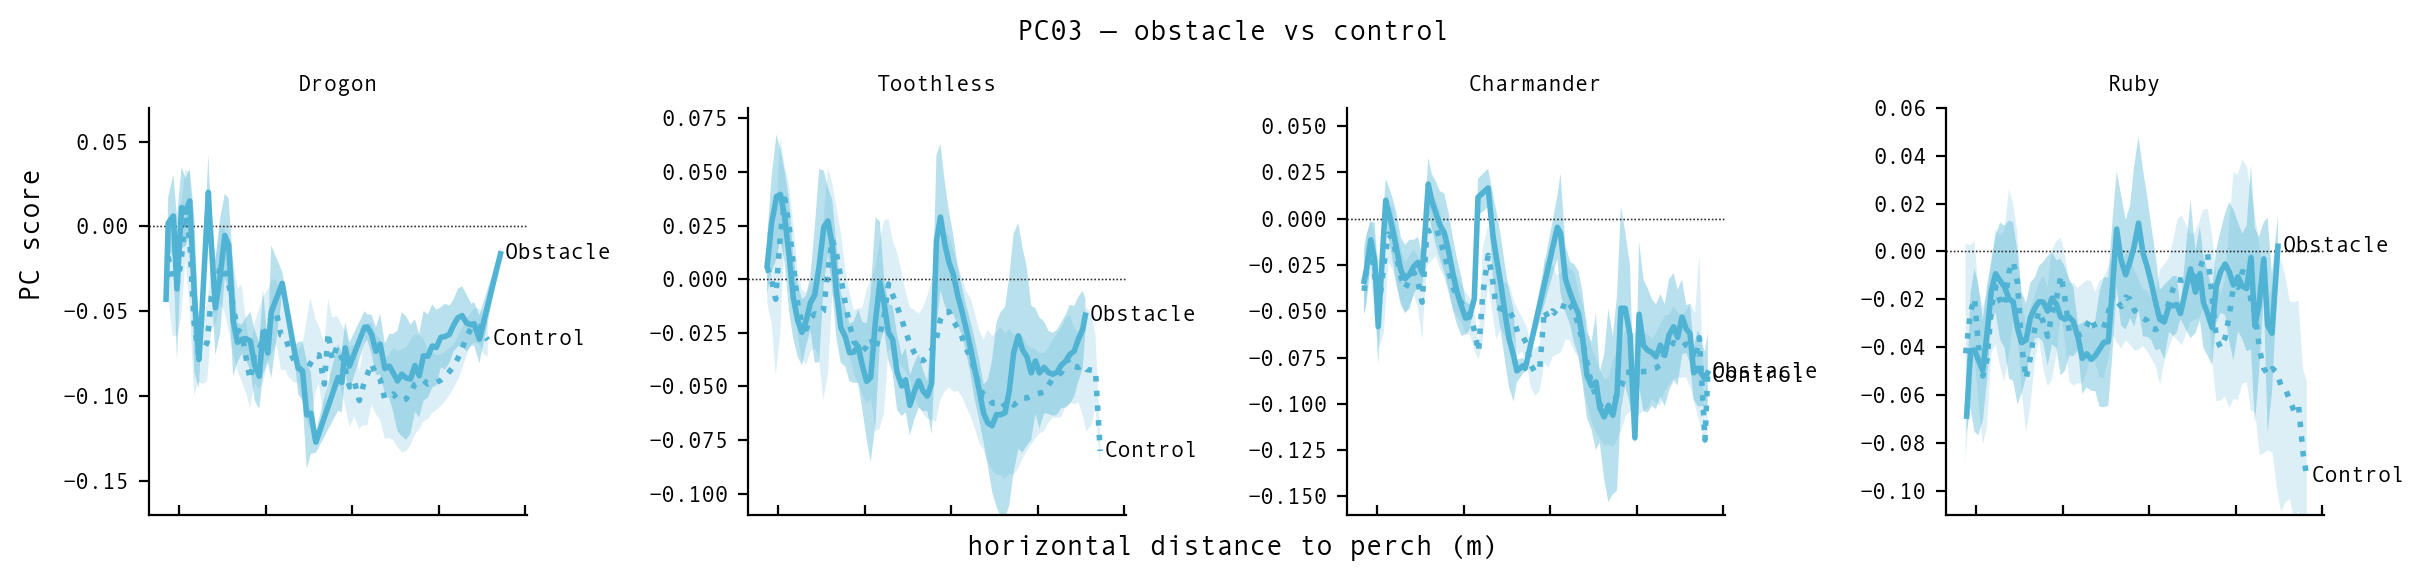

Saved: ../../figures/supplementary/S12_scores_obstacle_control_PC04.pdf


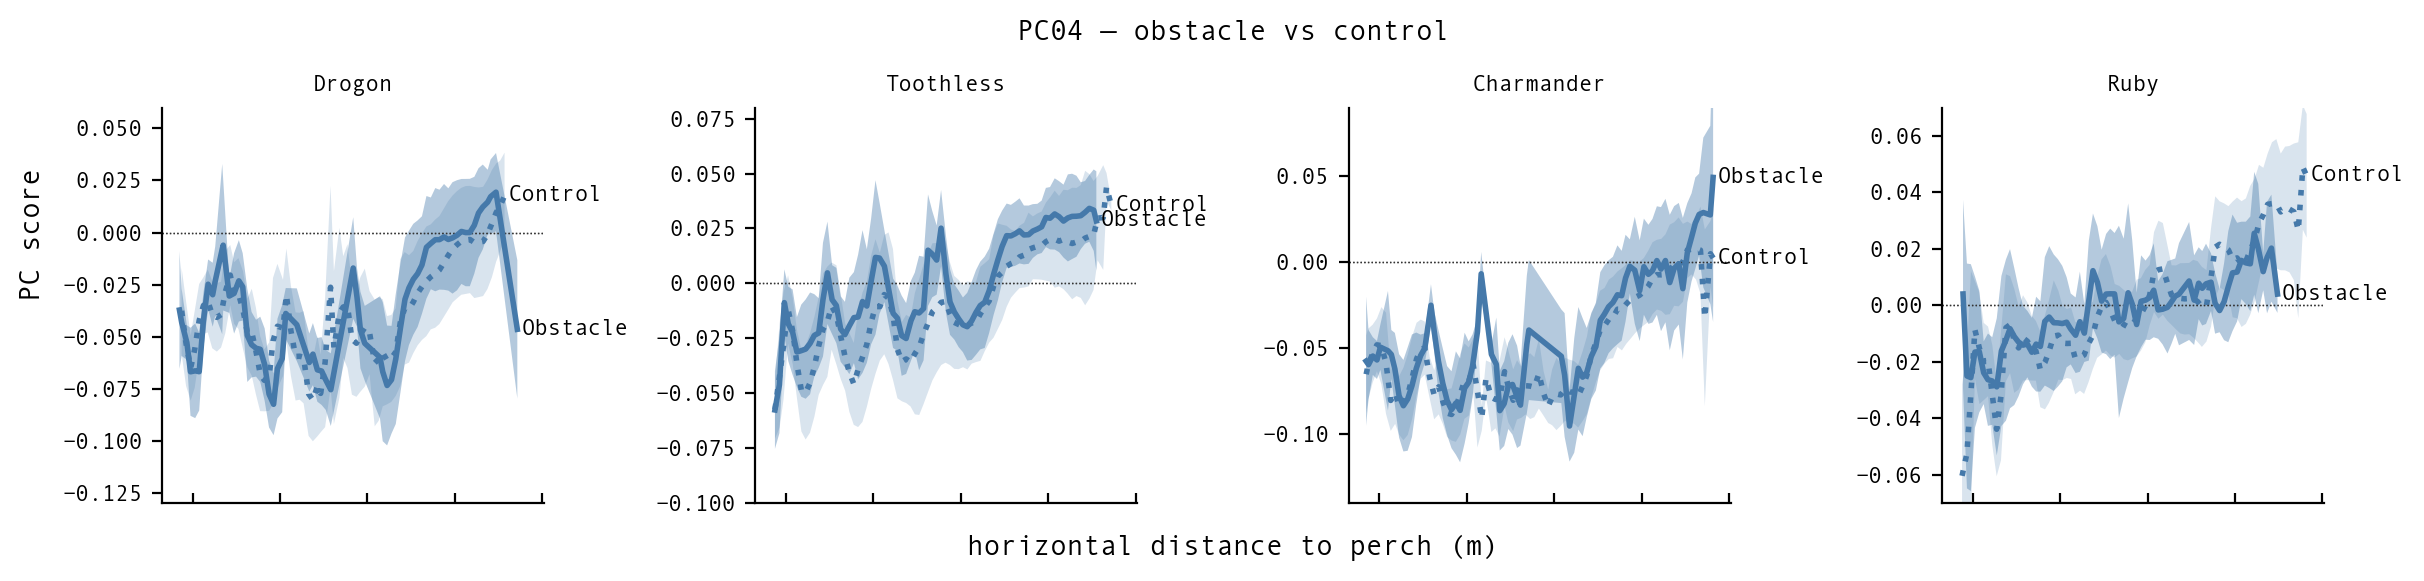

In [5]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_obstacle_control(scores_df, pc)
    plt.suptitle(f"{pc} — obstacle vs control", fontsize=10, y=1.05)
    save_figure(fig, f'../../figures/supplementary/S12_scores_obstacle_control_{pc}.pdf')
    plt.show()

### Observations from §12.2

- A sudden increase and decrease in **wing sweep** (Mode 3) is visible around the obstacle at the midpoint.
- There is a new, highly variable decrease in **collective pitching** (Mode 8) — the tail drops as the wings pitch up.
- A decrease and increase in **hand-wing sweep** (Mode 9) also appears around the obstacle.

**Wingbeat frequency caveat:** Between individuals, wingbeat frequency differs, which affects the binned means. More advanced methods that decompose the time-series dynamics of morphing flight would be required to compare across different flights and individuals with different wingbeat frequencies, but this is beyond the scope of this analysis.

## Mean Scores by Individual Under Different Contexts

> **§12.3**

Individual variation in morphing is high, as is the timing of manoeuvres. Below we show each hawk under three conditions: control (no obstacle, no weight), with obstacle, and with both obstacle and added weight (IMU).

The within-individual standard deviation is markedly smaller than the across-individual variation, demonstrating that each hawk uses a consistent personal morphing strategy. This consistency holds across modes and conditions — the morphing modes therefore capture repeatable, individual-level patterns of wing and tail use.

### Per-hawk scores — control flights

Saved: ../../figures/supplementary/S12_scores_per_hawk_PC01.pdf


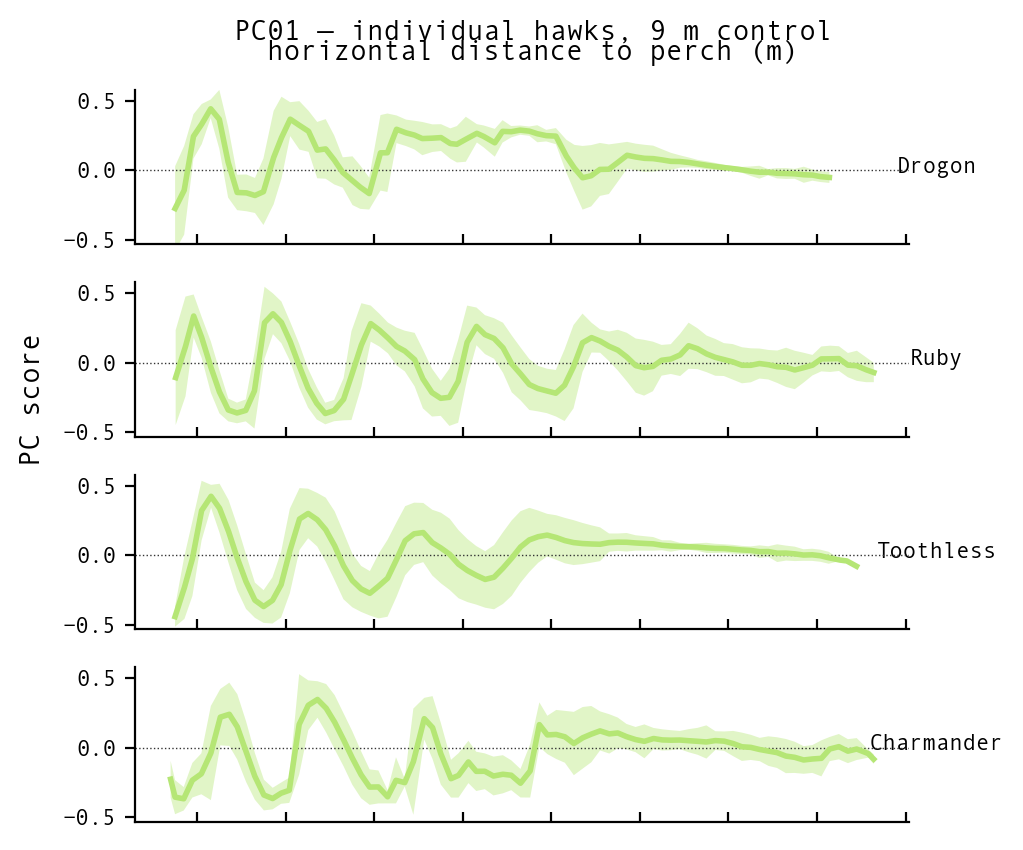

Saved: ../../figures/supplementary/S12_scores_per_hawk_PC02.pdf


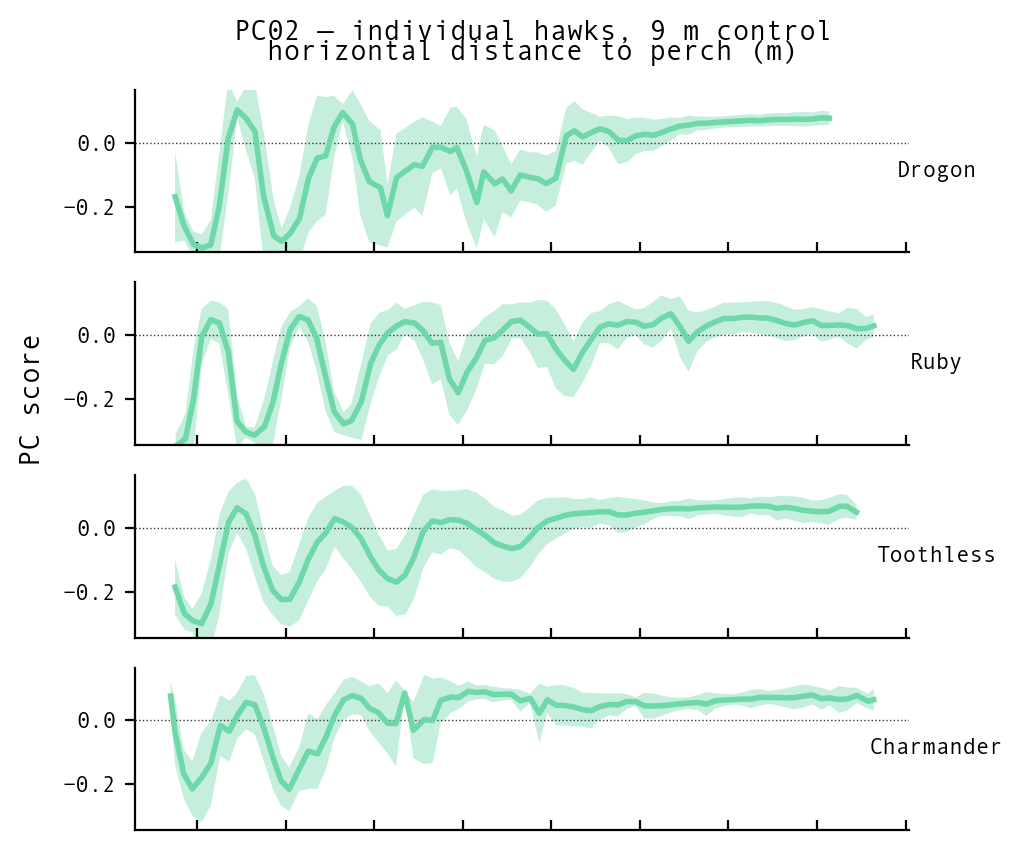

Saved: ../../figures/supplementary/S12_scores_per_hawk_PC03.pdf


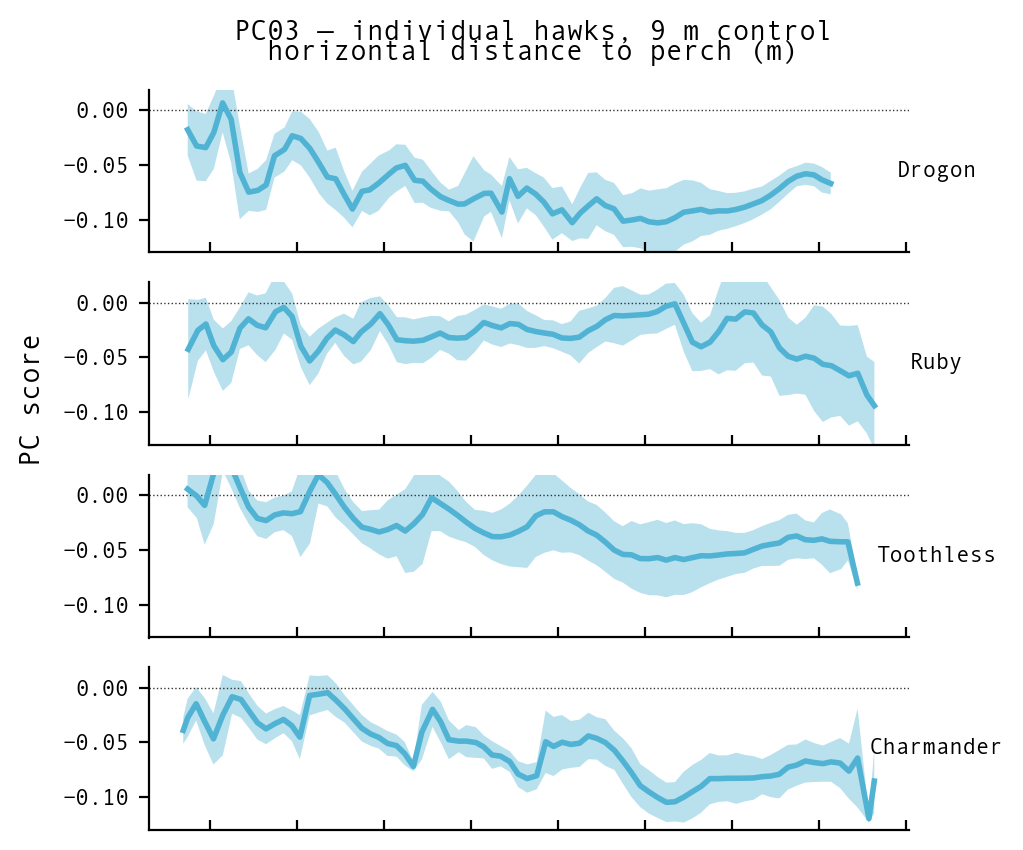

Saved: ../../figures/supplementary/S12_scores_per_hawk_PC04.pdf


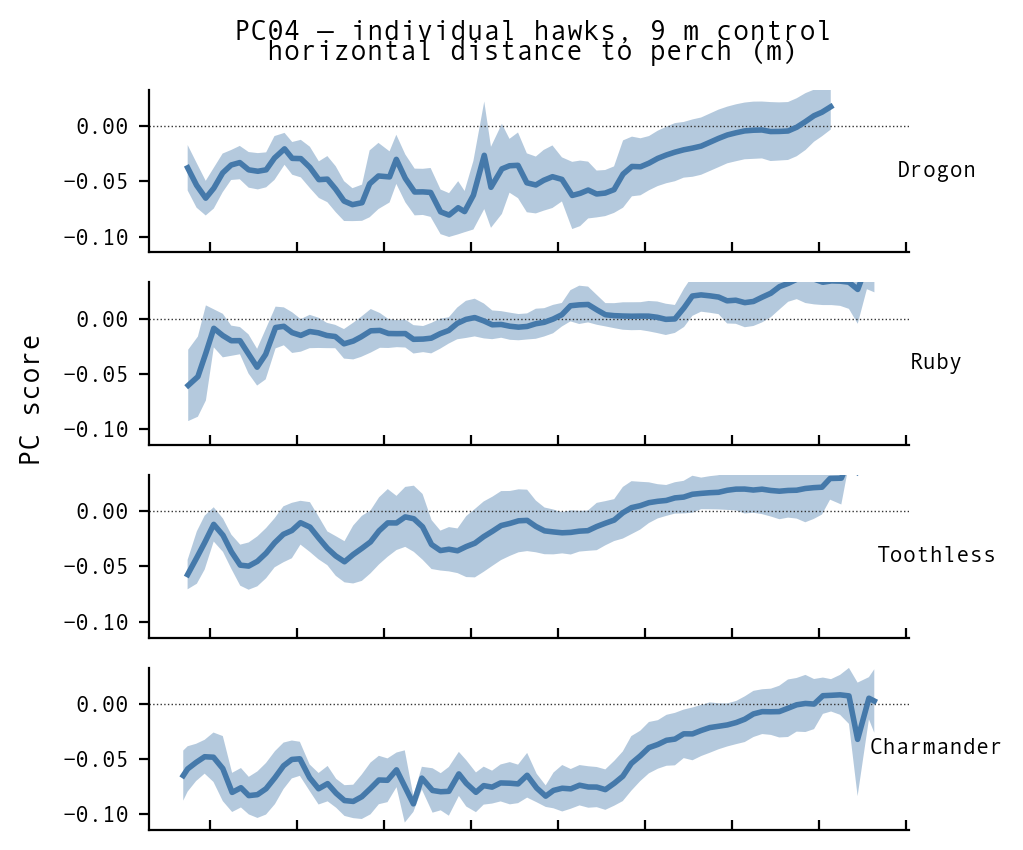

In [6]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_multi_bird(scores_df, pc, perchDist=9, obstacle=0, year=2020)
    plt.suptitle(f"{pc} — individual hawks, 9 m control", fontsize=10, y=1.05)
    save_figure(fig, f'../../figures/supplementary/S12_scores_per_hawk_{pc}.pdf')
    plt.show()

### Effect of added weight

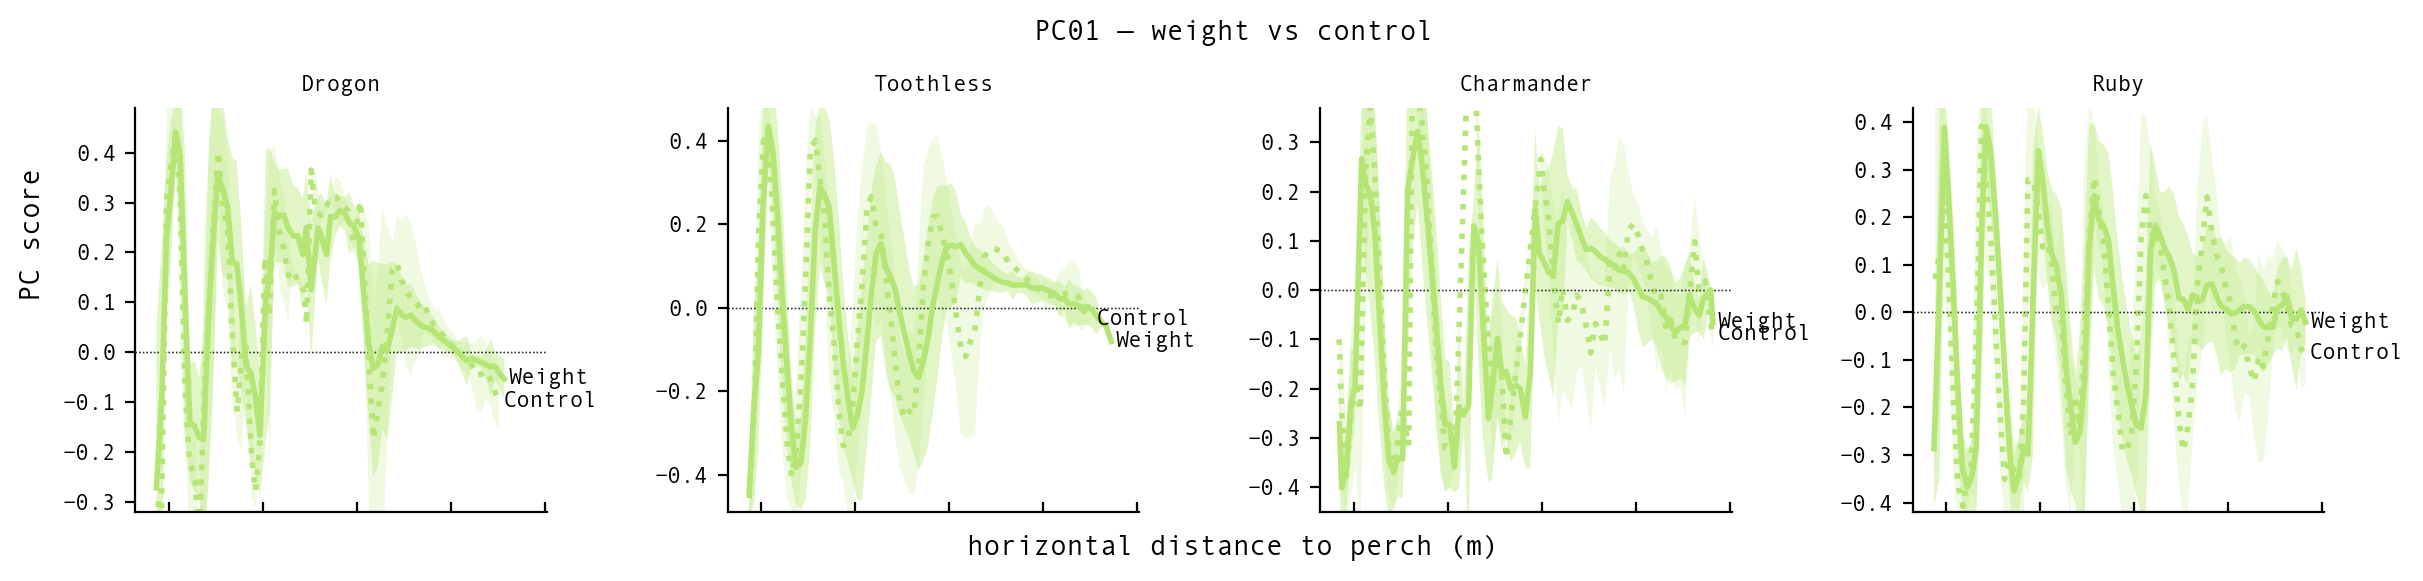

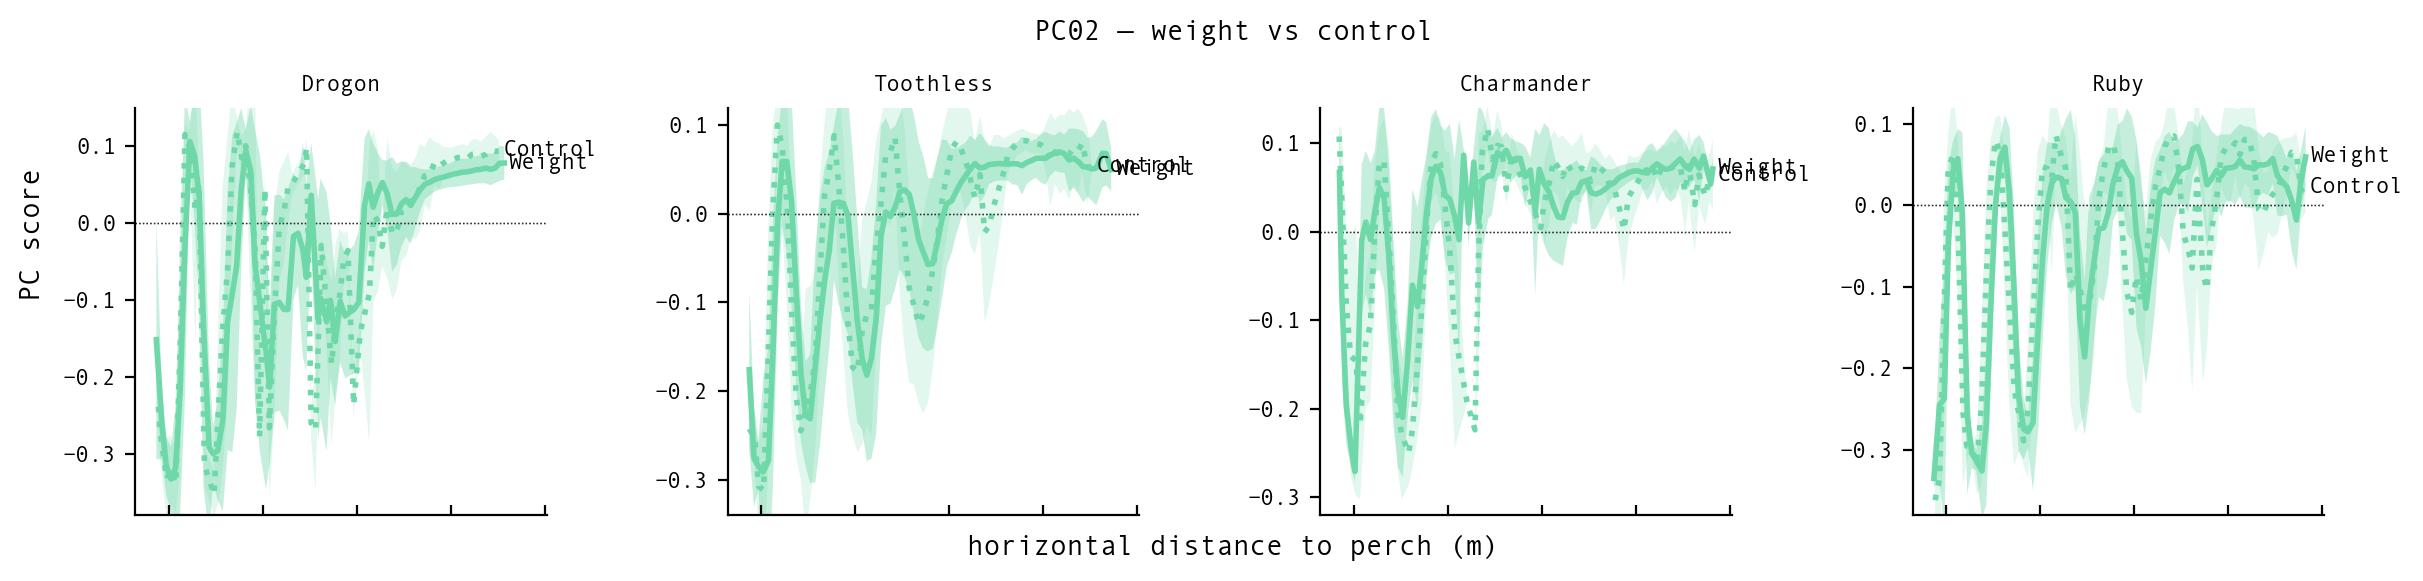

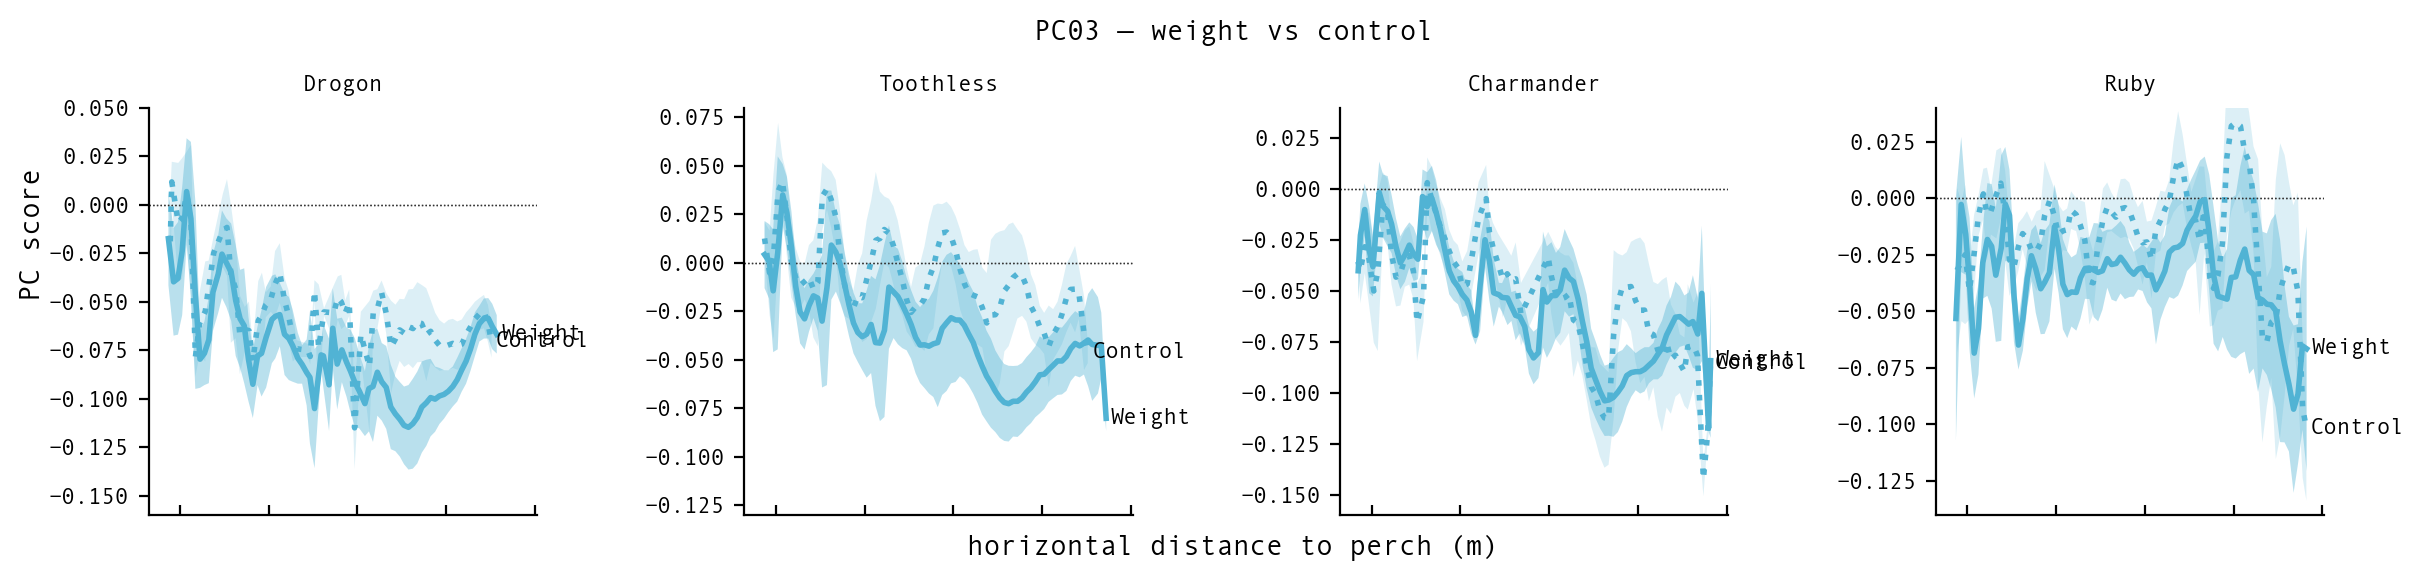

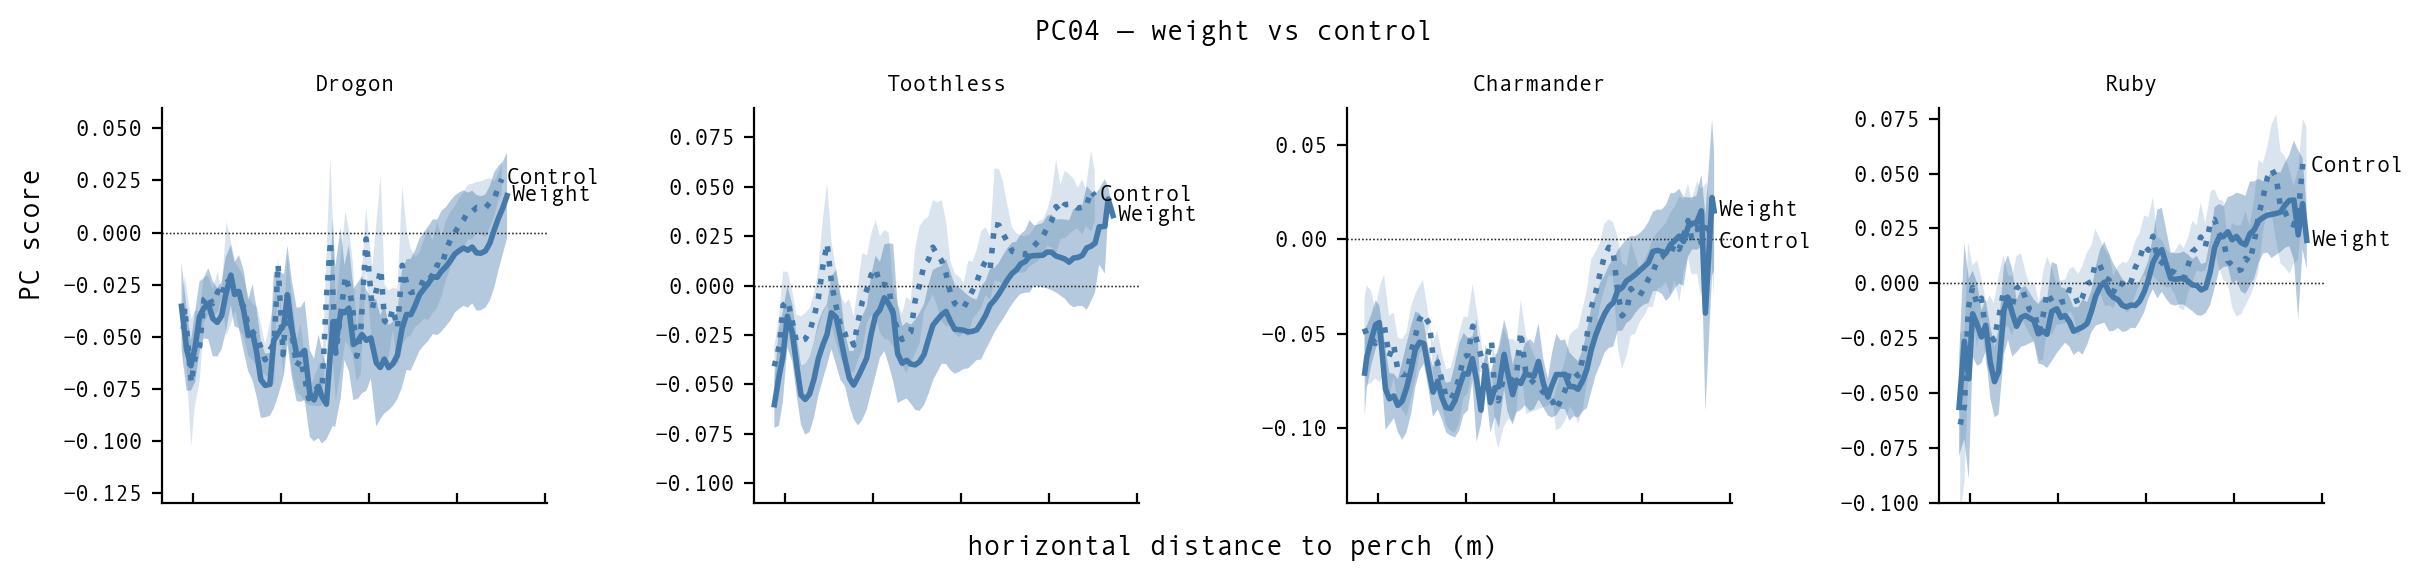

In [7]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_weight_control(scores_df, pc)
    plt.suptitle(f"{pc} — weight vs control", fontsize=10, y=1.05)
    plt.show()

### Naive vs experienced hawks

Two hawks (Drogon, Toothless) were recorded both as naive juveniles (2017) and as experienced adults (2020). The dotted line shows naive flights; the solid line shows experienced flights.

Saved: ../../figures/supplementary/S12_scores_naive_experienced_PC01.pdf


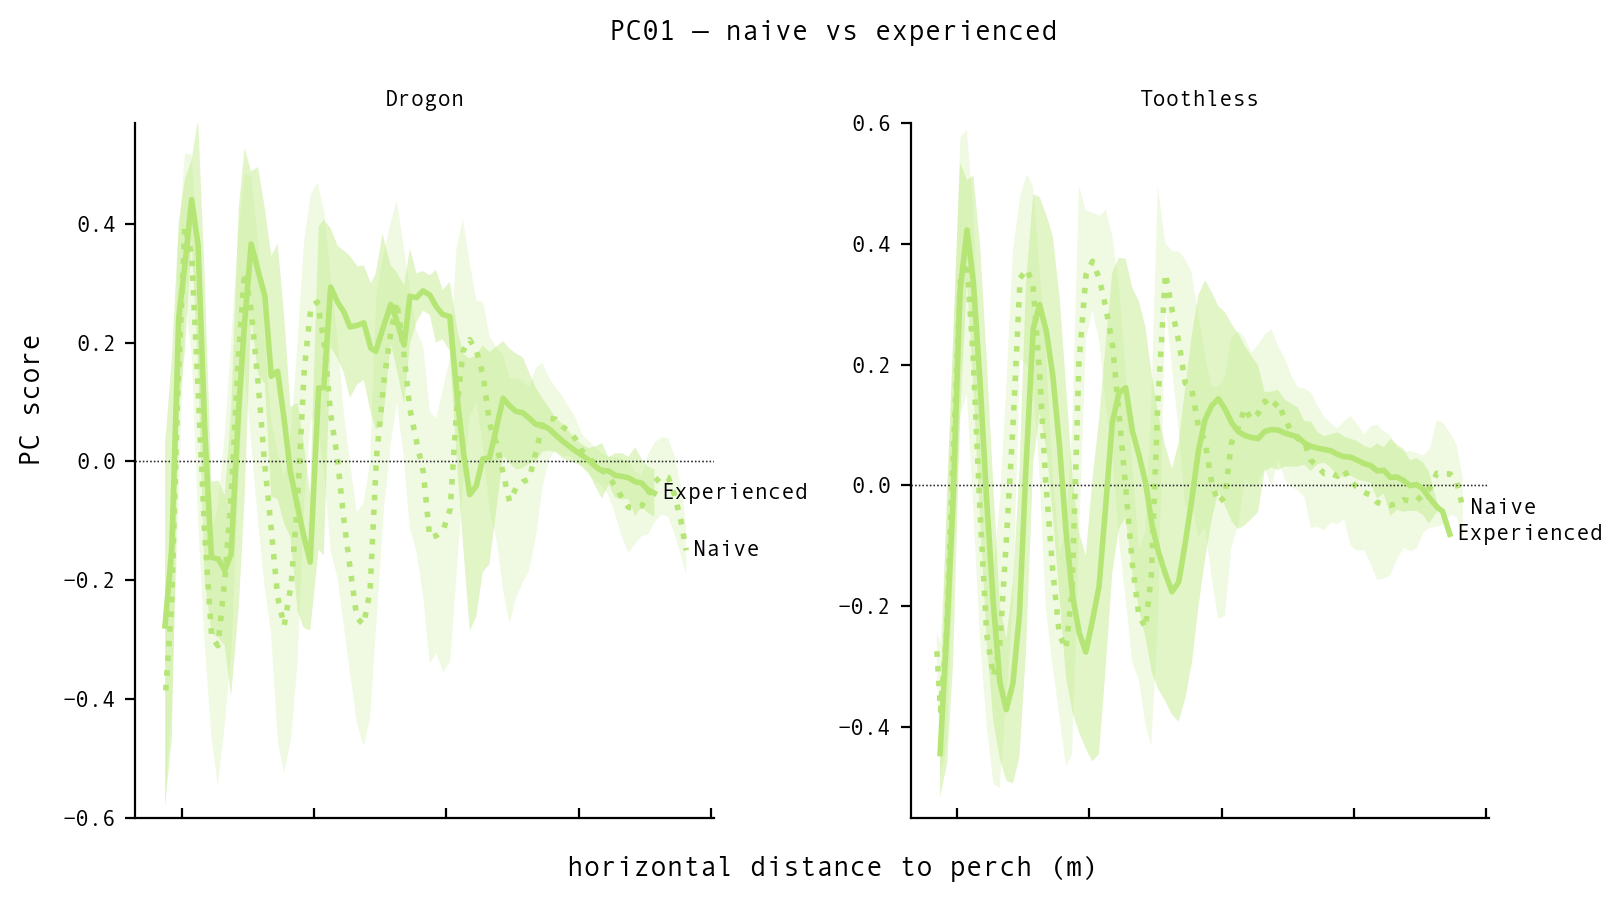

Saved: ../../figures/supplementary/S12_scores_naive_experienced_PC02.pdf


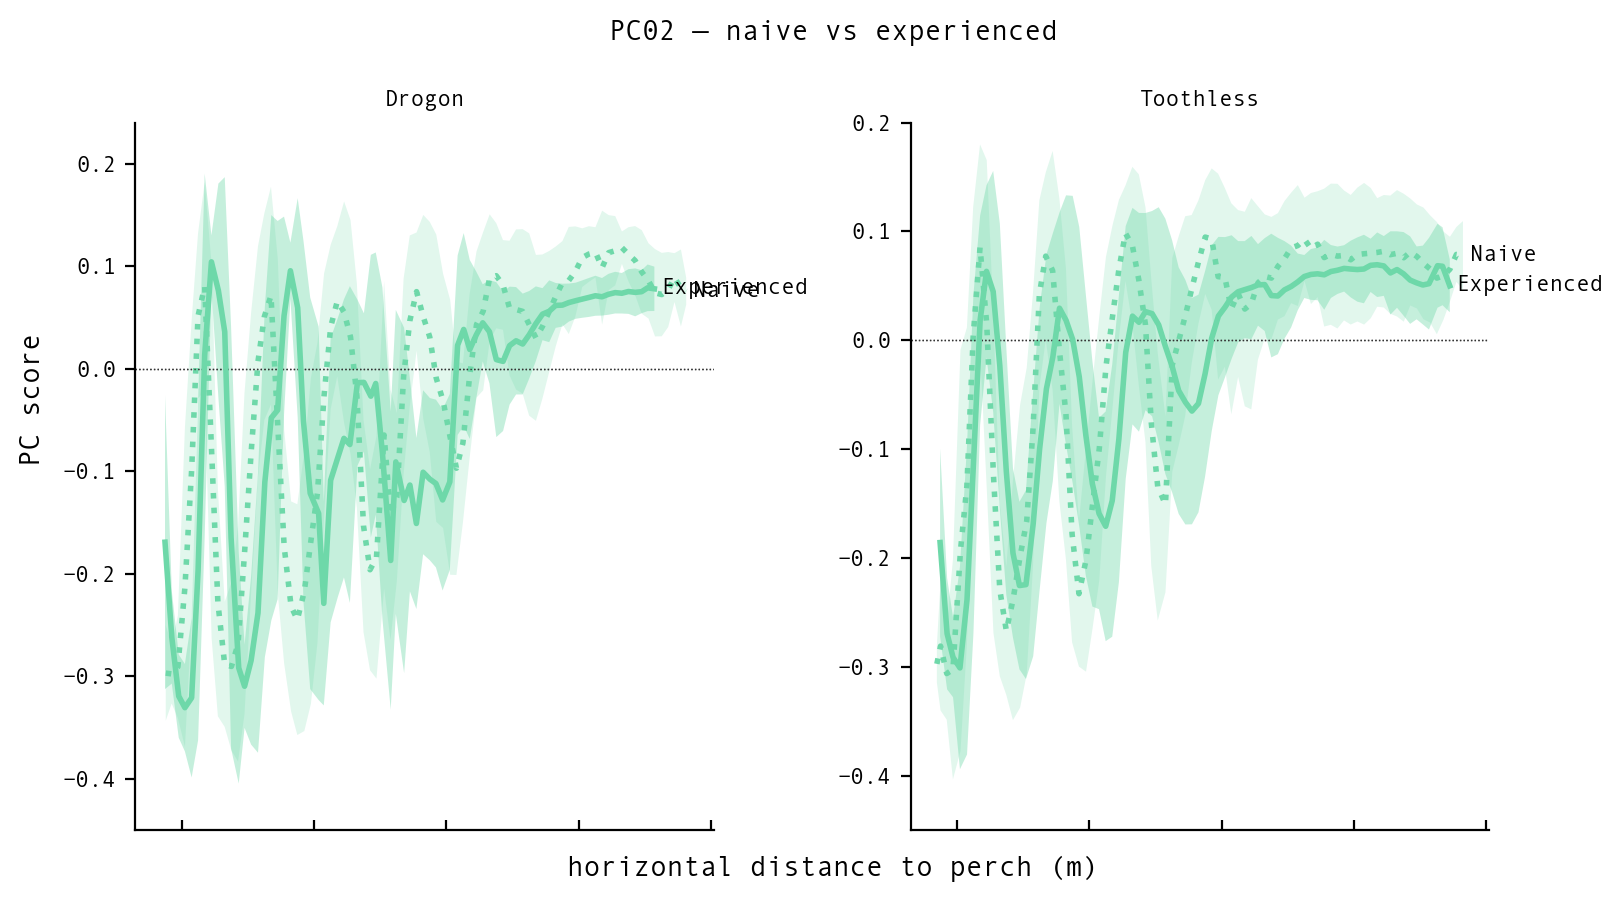

Saved: ../../figures/supplementary/S12_scores_naive_experienced_PC03.pdf


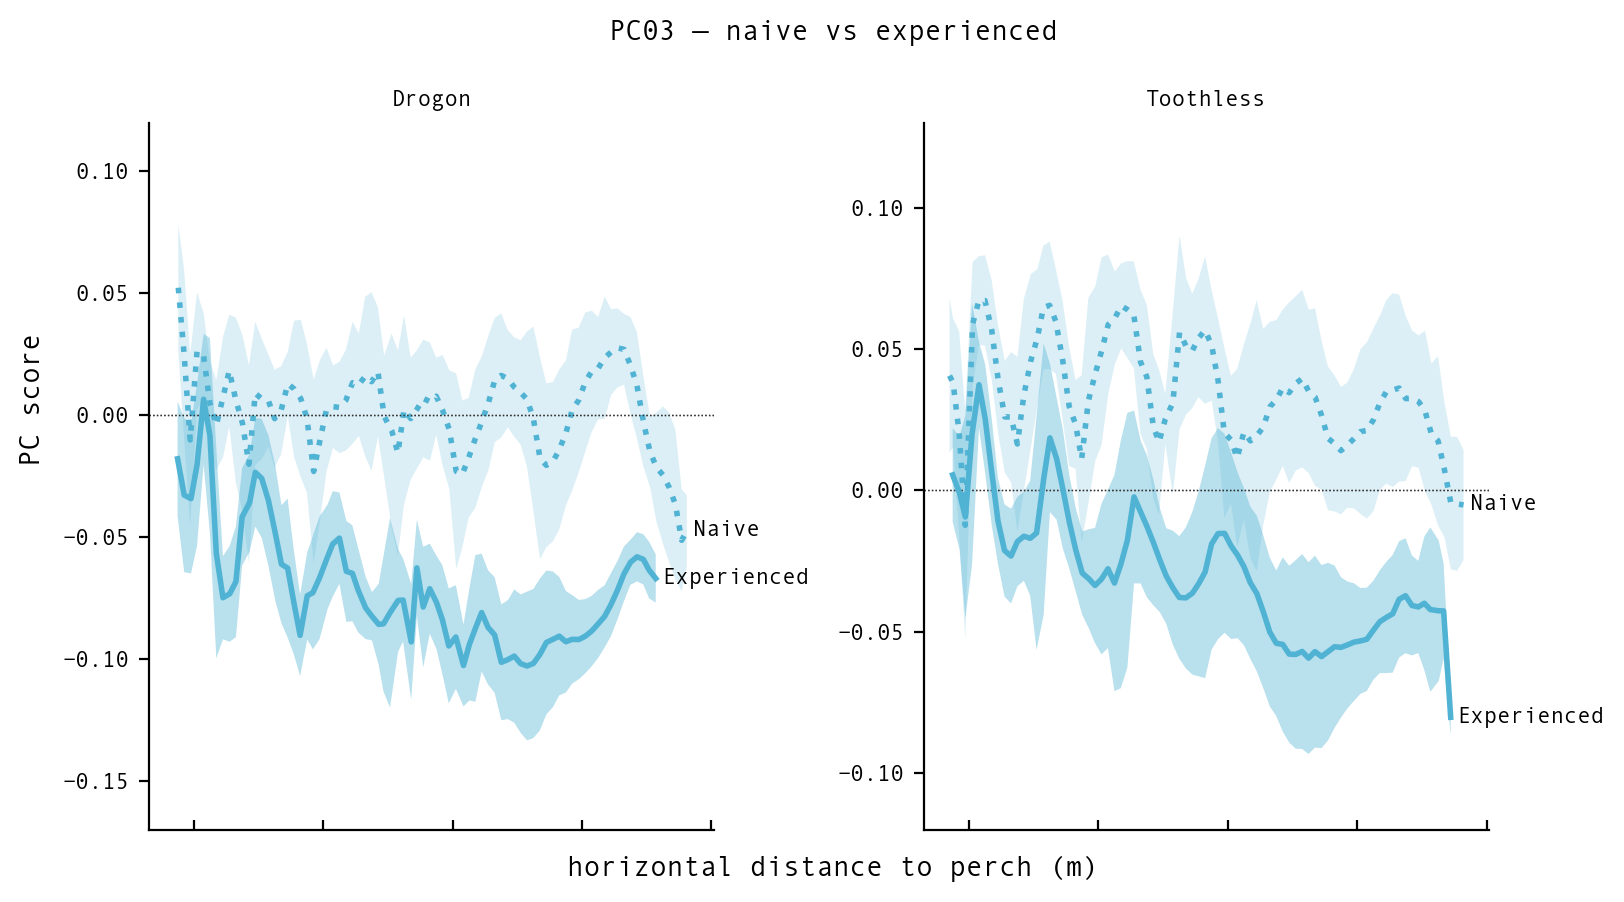

Saved: ../../figures/supplementary/S12_scores_naive_experienced_PC04.pdf


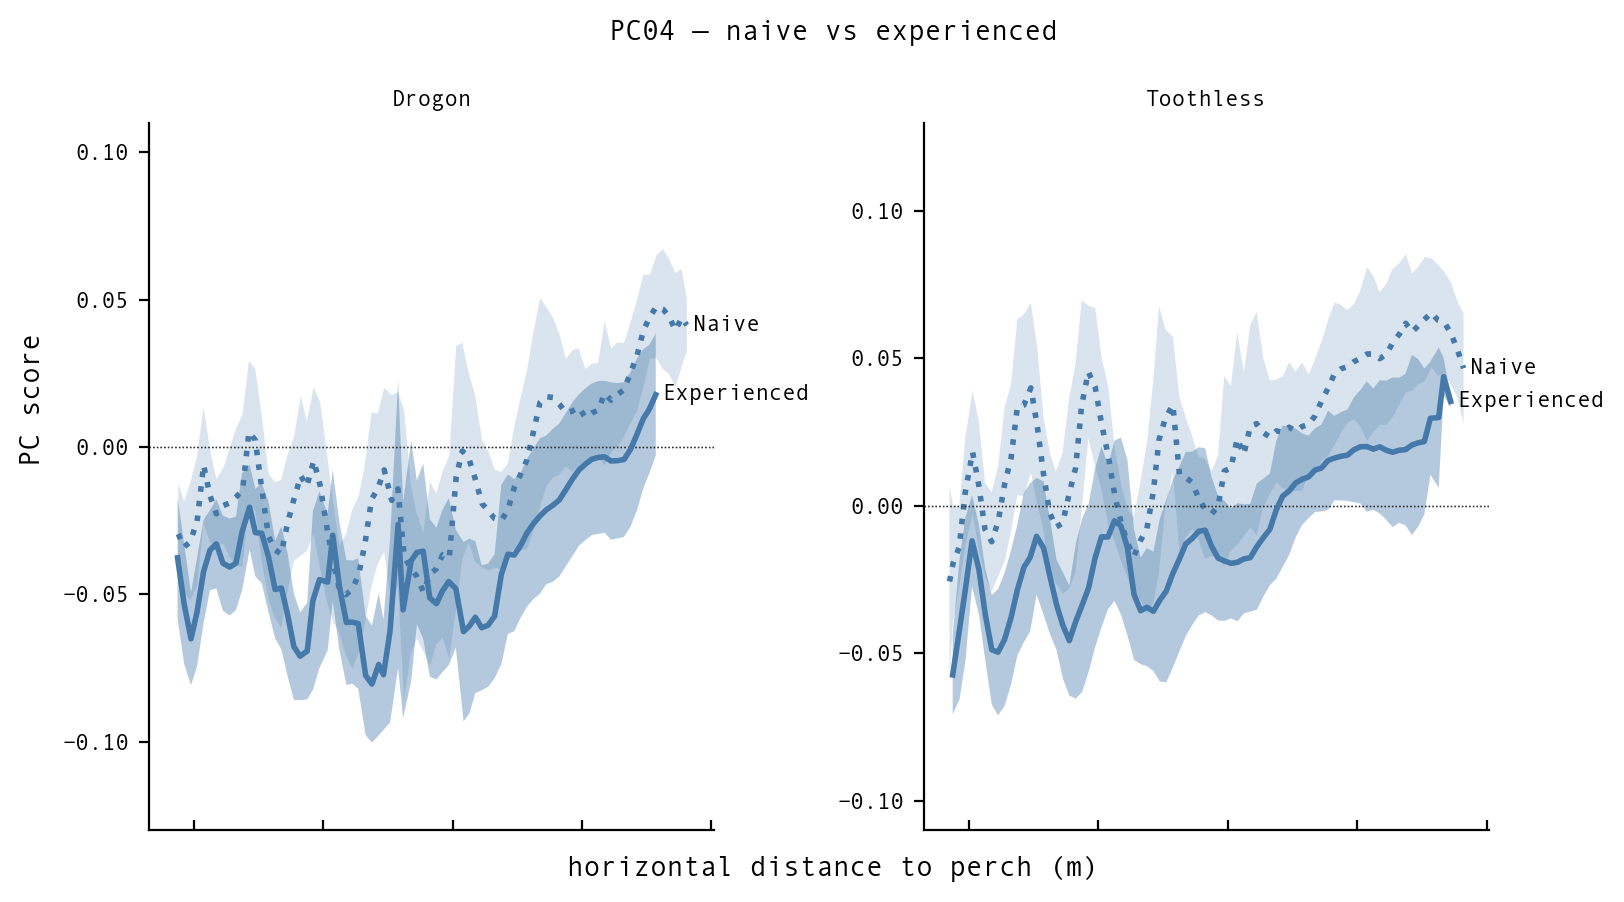

In [8]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_naive_control(scores_df, pc,
                                         hawkname_list=("Drogon", "Toothless"))
    plt.suptitle(f"{pc} — naive vs experienced", fontsize=10, y=1.05)
    save_figure(fig, f'../../figures/supplementary/S12_scores_naive_experienced_{pc}.pdf')
    plt.show()

## Summary

The morphing mode scores reveal structured temporal dynamics across flight contexts:

- **Wingbeat cycles** are clearly visible in Modes 1–4 during flapping, with amplitude decreasing and span increasing as the hawk accelerates.
- **Flapping-to-gliding transitions** occur in longer flights (9–12 m), with maximum wingspan during the glide and gradual reductions on approach.
- **Mode-specific landmarks:** A forward-sweep peak (~1.5 m before perch), maximum tail spread at landing (~0.3 m), and a counter-pitching "shrug" (~1 m) are consistent across flight distances.
- **Obstacle avoidance** introduces characteristic perturbations in sweep, collective pitching, and hand-wing shape near the midpoint obstacle.
- **Individual consistency** is high — within-hawk variation is substantially smaller than between-hawk variation across all conditions.
- **Experience effects** show that juvenile hawks use qualitatively similar but less consistent morphing patterns compared to the same individuals recorded as experienced adults.

**Note on mode ordering:** Collective pitching (PC08) has been repositioned for clarity throughout this notebook; scores are not strictly ordered by variance explained.

These results demonstrate that morphing shape modes capture the full temporal dynamics of hawk flight morphing, from wingbeat oscillations to condition-specific adjustments.

---

## References

- Carruthers, A. C., Thomas, A. L. R. & Taylor, G. K. (2007). Automatic aeroelastic devices in the wings of a steppe eagle *Aquila nipalensis*. *Journal of Experimental Biology*, 210, 4136–4149.
- KleinHeerenbrink, M., France, L. A., Brighton, C. H. & Taylor, G. K. (2022). Optimization of avian perching manoeuvres. *Nature*, 607, 91–96.